In [16]:
%matplotlib inline
import json
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
paths=[
    
    "/work/dlclarge2/aliy-maskgit/concept_graphs/results/output_all/single-body_2d_3classes/DiT/latent/discrete/sec_run/H32-train1/30-03-22-27_5000_1.6_256_500_6000_0.0001_None_1500_2.0_1/steps_acc.json",
    "/work/dlclarge2/aliy-maskgit/concept_graphs/results/output_all/single-body_2d_3classes/DiT/latent/discrete/sec_run/H32-train1/30-03-20-17_5000_1.6_256_500_6000_0.0001_None_1500_2.0_1/steps_acc.json",
    "/work/dlclarge2/aliy-maskgit/concept_graphs/results/output_all/single-body_2d_3classes/DiT/pixel/continuous/first_run/H32-train1/29-03-22-47_5000_1.6_256_500_6000_0.0001_None_1500_2.0_1/steps_acc.json",
    "/work/dlclarge2/aliy-maskgit/concept_graphs/results/output_all/single-body_2d_3classes/DiT/pixel/discrete/first_run/H32-train1/29-03-22-47_5000_1.6_256_500_6000_0.0001_None_1500_2.0_1/steps_acc.json",
    "/work/dlclarge2/aliy-maskgit/concept_graphs/results/output_all/single-body_2d_3classes/U-Net/latent/continuous/first_run/H32-train1/29-03-22-41_5000_1.6_256_500_6000_0.0001_None_1500_2.0_1/steps_acc.json",
    "/work/dlclarge2/aliy-maskgit/concept_graphs/results/output_all/single-body_2d_3classes/U-Net/latent/discrete/first_run/H32-train1/29-03-22-41_5000_1.6_256_500_6000_0.0001_None_1500_2.0_1/steps_acc.json",
    "/work/dlclarge2/aliy-maskgit/concept_graphs/results/output_all/single-body_2d_3classes/U-Net/pixel/continuous/sec_run/H32-train1/30-03-22-30_5000_1.6_256_500_6000_0.0001_None_1500_2.0_1/steps_acc.json",
    "/work/dlclarge2/aliy-maskgit/concept_graphs/results/output_all/single-body_2d_3classes/U-Net/pixel/discrete/sec_run/H32-train1/30-03-22-30_5000_1.6_256_500_6000_0.0001_None_1500_2.0_1/steps_acc.json"
]

In [7]:
def extract_title_from_path(path):
    components = path.split("/")
    
    model = components[-7]  
    representation = components[-6]  
    mode = components[-5]  
    
    title = f"{model} - {representation.capitalize()} ({mode.capitalize()})"
    return title

In [ ]:
line_styles = {
    "000": ("#22a6ff", "solid"),
    "001": ("#22a6ff", "dashed"),
    "010": ("#22a6ff", "dashdot"),
    "100": ("#22a6ff", "dotted"),
    "011": ("#ff95ca", "solid"),
    "101": ("#ff95ca", "dashed"),
    "110": ("#ff95ca", "dashdot"),
    "111": ("#ff00ae", "solid"),
}

def plot_data(data, title):
    plt.figure(figsize=(7, 5))

    for concept_code in line_styles.keys():
        steps = np.array(data[concept_code]["steps"])
        accuracies = np.array(data[concept_code]["accuracies"])

        color, linestyle = line_styles.get(concept_code, ("gray", "solid"))
        plt.plot(steps, accuracies, linestyle=linestyle, color=color, label=concept_code)

    plt.xscale("log")
    plt.xlabel("Optimization Steps")
    plt.ylabel("Accuracy (%)")
    plt.title(f"{title}")

    plt.legend(title="Concept Code", fontsize=9)
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)

    plt.show()



In [ ]:
def get_dict(path):
    
    with open(path, "r") as f:
        log_data = json.load(f)

    data_by_concept = {}

    for entry in log_data:
        step = entry["step"]
        concept_code = entry["concept_code"]
        accuracy = entry["accuracy"] * 100

        if concept_code not in data_by_concept:
            data_by_concept[concept_code] = {"steps": [], "accuracies": []}

        data_by_concept[concept_code]["steps"].append(step)
        data_by_concept[concept_code]["accuracies"].append(accuracy)
    sorted_keys = sorted(data_by_concept.keys())
    for concept_code in sorted_keys:
        steps = np.array(data_by_concept[concept_code]["steps"])
        accuracies = np.array(data_by_concept[concept_code]["accuracies"])

        sorted_indices = np.argsort(steps)
        data_by_concept[concept_code]["steps"] = steps[sorted_indices]
        data_by_concept[concept_code]["accuracies"] = accuracies[sorted_indices]
    title = extract_title_from_path(path)
    plot_data(data_by_concept,title)


In [ ]:
for path in paths:
    print(f"Processing file: {path}")
    if os.path.exists(path):
        get_dict(path)
    else:
        print(f"File not found: {path}")
        continue

Processing file: /work/dlclarge2/aliy-maskgit/concept_graphs/results/output_all/single-body_2d_3classes/DiT/latent/discrete/sec_run/H32-train1/30-03-22-27_5000_1.6_256_500_6000_0.0001_None_1500_2.0_1/steps_acc.json
Processing file: /work/dlclarge2/aliy-maskgit/concept_graphs/results/output_all/single-body_2d_3classes/DiT/latent/discrete/sec_run/H32-train1/30-03-20-17_5000_1.6_256_500_6000_0.0001_None_1500_2.0_1/steps_acc.json
File not found: /work/dlclarge2/aliy-maskgit/concept_graphs/results/output_all/single-body_2d_3classes/DiT/latent/discrete/sec_run/H32-train1/30-03-20-17_5000_1.6_256_500_6000_0.0001_None_1500_2.0_1/steps_acc.json
Processing file: /work/dlclarge2/aliy-maskgit/concept_graphs/results/output_all/single-body_2d_3classes/DiT/pixel/continuous/first_run/H32-train1/29-03-22-47_5000_1.6_256_500_6000_0.0001_None_1500_2.0_1/steps_acc.json
Processing file: /work/dlclarge2/aliy-maskgit/concept_graphs/results/output_all/single-body_2d_3classes/DiT/pixel/discrete/first_run/H32-t

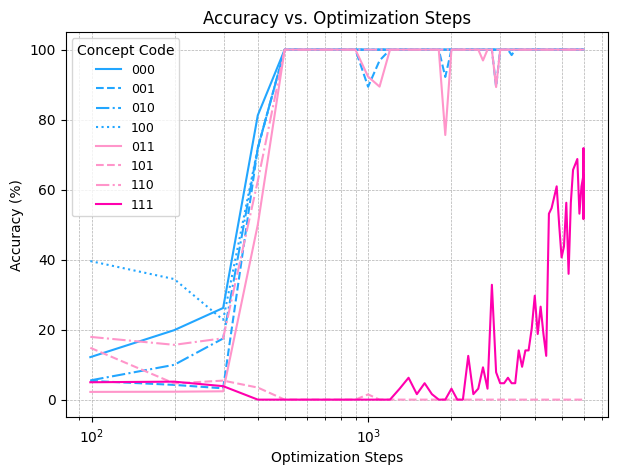